# 🔐 Fraud Detection — End-to-End ML Pipeline (Memory-Efficient)

| | |
|---|---|
| **Nama** | Rangga Timotius |
| **NIM** | 101032300137 |
| **Kelas** | TK46GAB |

---
## 📌 Deskripsi Proyek
Dataset berisi transaksi e-commerce berlabel `isFraud` (0=normal, 1=fraud).  
**Tujuan:** memprediksi probabilitas fraud menggunakan ML pipeline yang hemat RAM.

> ⚡ Notebook ini dioptimasi untuk Colab Free (RAM terbatas) dengan teknik:
> - **dtype downcasting** (float64 → float32, int64 → int32)
> - **Seleksi kolom** sebelum load penuh
> - **Sampling stratified** jika RAM masih tidak cukup
> - **Hapus variabel** yang tidak dipakai dengan `del` + `gc.collect()`


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. 🔗 Mount Google Drive & Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive berhasil di-mount!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive berhasil di-mount!


In [3]:
!pip install xgboost imbalanced-learn -q
print("✅ Library siap!")


✅ Library siap!


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, average_precision_score)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print("✅ Semua library berhasil di-import!")


✅ Semua library berhasil di-import!


## 2. 📂 Load Data (Memory-Efficient)

In [5]:
# ⚠️ SESUAIKAN PATH INI
DRIVE_PATH = '/content/drive/MyDrive/'   # ganti jika di subfolder

TRAIN_PATH = DRIVE_PATH + 'train_transaction.csv'
TEST_PATH  = DRIVE_PATH + 'test_transaction.csv'


In [6]:
# ── Fungsi untuk downcast dtype ──
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type).startswith('int'):
                for dtype in [np.int8, np.int16, np.int32]:
                    if c_min > np.iinfo(dtype).min and c_max < np.iinfo(dtype).max:
                        df[col] = df[col].astype(dtype); break
            else:
                for dtype in [np.float16, np.float32]:
                    if c_min > np.finfo(dtype).min and c_max < np.finfo(dtype).max:
                        df[col] = df[col].astype(dtype); break
    end_mem = df.memory_usage().sum() / 1024**2
    print(f"  Memori: {start_mem:.1f} MB → {end_mem:.1f} MB ({100*(start_mem-end_mem)/start_mem:.1f}% hemat)")
    return df


In [7]:
# ── Cek kolom & ukuran dulu tanpa load semua data ──
print("Membaca header untuk cek kolom...")
train_cols = pd.read_csv(TRAIN_PATH, nrows=0).columns.tolist()
print(f"Jumlah kolom train : {len(train_cols)}")
print(f"Kolom target       : {'isFraud' in train_cols}")


Membaca header untuk cek kolom...
Jumlah kolom train : 394
Kolom target       : True


In [8]:
# ── Pilih kolom yang akan dipakai (buang kolom V yang terlalu banyak) ──
# Kolom V (V1-V339) adalah hasil PCA — ambil subset saja untuk hemat RAM
import re
v_cols = [c for c in train_cols if re.match(r'^V\d+$', c)]
# Ambil setiap 3 kolom V (V1,V4,V7,...) untuk representasi
v_selected = v_cols[::3]

# Kolom utama non-V
core_cols = [c for c in train_cols if not re.match(r'^V\d+$', c)]

USE_COLS = core_cols + v_selected
print(f"Total kolom dipilih : {len(USE_COLS)} dari {len(train_cols)}")
print(f"  - Core cols : {len(core_cols)}")
print(f"  - V cols    : {len(v_selected)} (dari {len(v_cols)} total)")


Total kolom dipilih : 168 dari 394
  - Core cols : 55
  - V cols    : 113 (dari 339 total)


In [9]:
# ── Load train dengan kolom terpilih ──
print("Loading train_transaction.csv (kolom terpilih)...")
train = pd.read_csv(TRAIN_PATH, usecols=USE_COLS)
train = reduce_mem_usage(train)
print(f"✅ Train shape : {train.shape}")
gc.collect()


Loading train_transaction.csv (kolom terpilih)...
  Memori: 756.9 MB → 256.2 MB (66.1% hemat)
✅ Train shape : (590540, 168)


0

In [10]:
# ── Load test ──
test_use_cols = [c for c in USE_COLS if c != 'isFraud']
print("Loading test_transaction.csv...")
test = pd.read_csv(TEST_PATH, usecols=[c for c in test_use_cols if c in pd.read_csv(TEST_PATH, nrows=0).columns])
test = reduce_mem_usage(test)
print(f"✅ Test shape  : {test.shape}")
gc.collect()


Loading test_transaction.csv...
  Memori: 645.6 MB → 221.3 MB (65.7% hemat)
✅ Test shape  : (506691, 167)


0

## 3. 📊 Eksplorasi Data (EDA)

In [11]:
print("=== Distribusi Target (isFraud) ===")
vc = train['isFraud'].value_counts()
print(vc)
fraud_pct = vc[1] / len(train) * 100
print(f"\nFraud  : {fraud_pct:.2f}%")
print(f"Normal : {100-fraud_pct:.2f}%")
print("\n⚠️ Dataset sangat imbalanced!" if fraud_pct < 5 else "")


=== Distribusi Target (isFraud) ===
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud  : 3.50%
Normal : 96.50%

⚠️ Dataset sangat imbalanced!


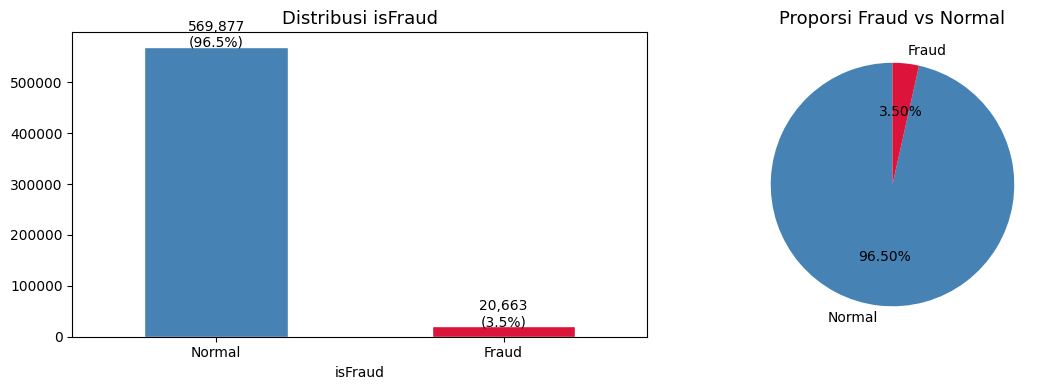

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc.plot(kind='bar', ax=axes[0], color=['steelblue','crimson'], edgecolor='white', width=0.5)
axes[0].set_title('Distribusi isFraud', fontsize=13)
axes[0].set_xticklabels(['Normal','Fraud'], rotation=0)
for i, v in enumerate(vc):
    axes[0].text(i, v+200, f'{v:,}\n({v/len(train)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(vc, labels=['Normal','Fraud'], autopct='%1.2f%%',
            colors=['steelblue','crimson'], startangle=90)
axes[1].set_title('Proporsi Fraud vs Normal', fontsize=13)
plt.tight_layout(); plt.show()


In [13]:
print("=== Missing Values (Top 15) ===")
miss = train.isnull().mean().sort_values(ascending=False).head(15)
print((miss * 100).round(2).to_string())


=== Missing Values (Top 15) ===
dist2    93.63
D7       93.41
D13      89.51
D14      89.47
D12      89.04
D6       87.61
D9       87.31
D8       87.31
V148     86.12
V154     86.12
V157     86.12
V139     86.12
V142     86.12
V163     86.12
V166     86.12


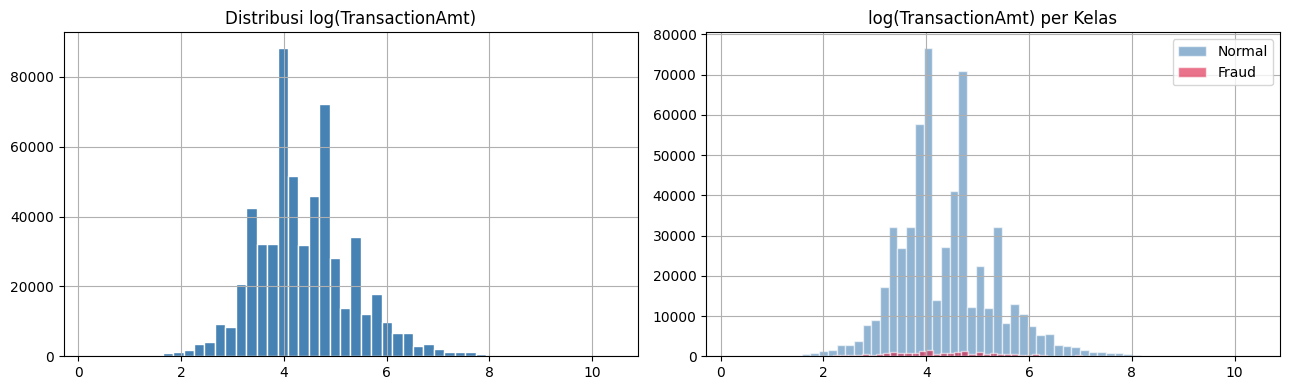

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
np.log1p(train['TransactionAmt']).hist(bins=50, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Distribusi log(TransactionAmt)', fontsize=12)

for label, color in [(0,'steelblue'),(1,'crimson')]:
    np.log1p(train[train['isFraud']==label]['TransactionAmt']).hist(
        bins=60, alpha=0.6, color=color, edgecolor='white',
        label='Normal' if label==0 else 'Fraud', ax=axes[1])
axes[1].set_title('log(TransactionAmt) per Kelas', fontsize=12)
axes[1].legend()
plt.tight_layout(); plt.show()


## 4. 🔧 Preprocessing

In [15]:
# Pisahkan target & TransactionID
y = train['isFraud'].astype(np.int8)
test_ids = test['TransactionID'].copy()

X = train.drop(columns=['isFraud'])
del train; gc.collect()   # ← bebaskan RAM segera
print(f"✅ train dihapus dari RAM | X shape: {X.shape}")


✅ train dihapus dari RAM | X shape: (590540, 167)


In [16]:
# Hapus kolom missing > 70%
thresh = 0.70
drop_cols = X.columns[X.isnull().mean() > thresh].tolist()
print(f"Kolom dihapus (missing > 70%): {len(drop_cols)}")
X = X.drop(columns=drop_cols)
test = test.drop(columns=[c for c in drop_cols if c in test.columns])
print(f"Shape setelah drop: {X.shape}")


Kolom dihapus (missing > 70%): 62
Shape setelah drop: (590540, 105)


In [17]:
# Encoding kategorikal
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Kolom kategorikal: {len(cat_cols)}")

le = LabelEncoder()
for col in cat_cols:
    all_vals = pd.concat([X[col], test[col] if col in test.columns else pd.Series()]).astype(str)
    le.fit(all_vals)
    X[col]   = le.transform(X[col].astype(str)).astype(np.int16)
    if col in test.columns:
        test[col] = le.transform(test[col].astype(str)).astype(np.int16)

print("✅ Label Encoding selesai")


Kolom kategorikal: 13
✅ Label Encoding selesai


In [18]:
# Imputasi median
print("Imputasi missing values (median)...")
num_cols = X.select_dtypes(include=np.number).columns.tolist()
imputer = SimpleImputer(strategy='median')
X[num_cols]    = imputer.fit_transform(X[num_cols]).astype(np.float32)

test_num = [c for c in num_cols if c in test.columns]
test[test_num] = imputer.transform(test[test_num]).astype(np.float32)

print(f"✅ Imputasi selesai. Missing: {X.isnull().sum().sum()}")
gc.collect()


Imputasi missing values (median)...
✅ Imputasi selesai. Missing: 0


0

In [19]:
# Feature engineering
X['log_TransactionAmt']    = np.log1p(X['TransactionAmt']).astype(np.float32)
test['log_TransactionAmt'] = np.log1p(test['TransactionAmt']).astype(np.float32)
print("✅ Feature engineering selesai")
print(f"RAM train X: {X.memory_usage().sum()/1024**2:.1f} MB")


✅ Feature engineering selesai
RAM train X: 238.8 MB


## 5. ⚖️ Split Data & Handle Class Imbalance

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
del X; gc.collect()
print(f"Train : {X_train.shape[0]:,} | Val : {X_val.shape[0]:,}")
print(f"Fraud rate train : {y_train.mean()*100:.2f}%")


Train : 472,432 | Val : 118,108
Fraud rate train : 3.50%


In [21]:
# SMOTE — terapkan pada training set saja
print("Menerapkan SMOTE...")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
del X_train; gc.collect()

print(f"Shape setelah SMOTE : {X_train_sm.shape}")
print(f"Distribusi:\n{pd.Series(y_train_sm).value_counts()}")


Menerapkan SMOTE...
Shape setelah SMOTE : (911804, 106)
Distribusi:
isFraud
0    455902
1    455902
Name: count, dtype: int64


## 6. 🤖 Model Training

In [22]:
results = {}

def evaluate(name, model, Xtr, ytr, Xv, yv):
    t = time.time()
    model.fit(Xtr, ytr)
    elapsed = time.time()-t
    yp = model.predict_proba(Xv)[:,1]
    auc = roc_auc_score(yv, yp)
    ap  = average_precision_score(yv, yp)
    rep = classification_report(yv, (yp>=0.5).astype(int), output_dict=True)
    f1  = rep['1']['f1-score']
    results[name] = {'AUC-ROC':round(auc,4),'Avg-Precision':round(ap,4),
                     'F1-Fraud':round(f1,4),'Time(s)':round(elapsed,1)}
    print(f"✅ {name:30s} | AUC: {auc:.4f} | F1: {f1:.4f} | Time: {elapsed:.1f}s")
    return model, yp


In [23]:
print("🚀 Training Logistic Regression...")
lr_model, lr_prob = evaluate(
    'Logistic Regression',
    LogisticRegression(max_iter=500, class_weight='balanced', random_state=42, n_jobs=-1),
    X_train_sm, y_train_sm, X_val, y_val
)


🚀 Training Logistic Regression...
✅ Logistic Regression            | AUC: 0.6789 | F1: 0.0974 | Time: 130.7s


In [24]:
print("🚀 Training Random Forest (n=100)...")
rf_model, rf_prob = evaluate(
    'Random Forest',
    RandomForestClassifier(n_estimators=100, max_depth=10,
                           class_weight='balanced', random_state=42, n_jobs=-1),
    X_train_sm, y_train_sm, X_val, y_val
)


🚀 Training Random Forest (n=100)...
✅ Random Forest                  | AUC: 0.8712 | F1: 0.4574 | Time: 280.2s


In [25]:
print("🚀 Training XGBoost...")
scale_pos = int((y_train_sm==0).sum()/(y_train_sm==1).sum())
xgb_model, xgb_prob = evaluate(
    'XGBoost',
    xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                      scale_pos_weight=scale_pos, tree_method='hist',
                      use_label_encoder=False, eval_metric='auc',
                      random_state=42, n_jobs=-1, verbosity=0),
    X_train_sm, y_train_sm, X_val, y_val
)


🚀 Training XGBoost...
✅ XGBoost                        | AUC: 0.8968 | F1: 0.5349 | Time: 54.8s


In [26]:
results_df = pd.DataFrame(results).T.sort_values('AUC-ROC', ascending=False)
print("\n=== Rangkuman Hasil Model ===")
print(results_df.to_string())



=== Rangkuman Hasil Model ===
                     AUC-ROC  Avg-Precision  F1-Fraud  Time(s)
XGBoost               0.8968         0.5471    0.5349     54.8
Random Forest         0.8712         0.4842    0.4574    280.2
Logistic Regression   0.6789         0.0688    0.0974    130.7


## 7. ⚙️ Hyperparameter Tuning (XGBoost)

In [27]:
param_dist = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos, tree_method='hist',
    use_label_encoder=False, eval_metric='auc',
    random_state=42, n_jobs=-1, verbosity=0
)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
search = RandomizedSearchCV(xgb_base, param_dist, n_iter=15, cv=cv,
                            scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1)

print("🔧 RandomizedSearchCV berjalan (estimasi 5-10 menit)...")
search.fit(X_train_sm, y_train_sm)
print(f"\n✅ Best Params : {search.best_params_}")
print(f"✅ Best CV AUC : {search.best_score_:.4f}")


🔧 RandomizedSearchCV berjalan (estimasi 5-10 menit)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ Best Params : {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
✅ Best CV AUC : 0.9982


In [28]:
best_xgb = search.best_estimator_
y_prob_tuned = best_xgb.predict_proba(X_val)[:,1]
auc_tuned = roc_auc_score(y_val, y_prob_tuned)
ap_tuned  = average_precision_score(y_val, y_prob_tuned)

print(f"=== XGBoost Setelah Tuning ===")
print(f"AUC-ROC          : {auc_tuned:.4f}")
print(f"Average Precision: {ap_tuned:.4f}")
print(f"\nSebelum tuning AUC : {results['XGBoost']['AUC-ROC']:.4f}")
print(f"Sesudah tuning AUC : {auc_tuned:.4f}")


=== XGBoost Setelah Tuning ===
AUC-ROC          : 0.9549
Average Precision: 0.7573

Sebelum tuning AUC : 0.8968
Sesudah tuning AUC : 0.9549


## 8. 📊 Evaluasi Model

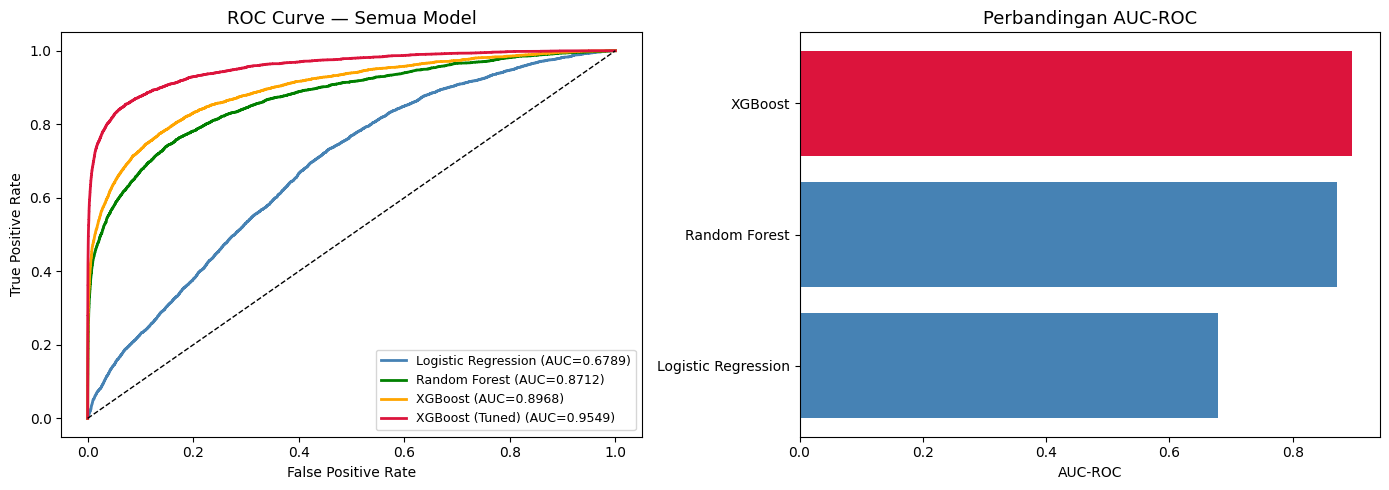

In [29]:
# ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for prob, name, color in [
    (lr_prob,      'Logistic Regression', 'steelblue'),
    (rf_prob,      'Random Forest',       'green'),
    (xgb_prob,     'XGBoost',             'orange'),
    (y_prob_tuned, 'XGBoost (Tuned)',     'crimson'),
]:
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.4f})')

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Semua Model', fontsize=13)
axes[0].legend(fontsize=9)

# AUC bar
res_plot = pd.DataFrame(results).T.sort_values('AUC-ROC', ascending=False)
axes[1].barh(res_plot.index, res_plot['AUC-ROC'].astype(float),
             color=['crimson' if i==0 else 'steelblue' for i in range(len(res_plot))])
axes[1].set_title('Perbandingan AUC-ROC', fontsize=13)
axes[1].set_xlabel('AUC-ROC'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()


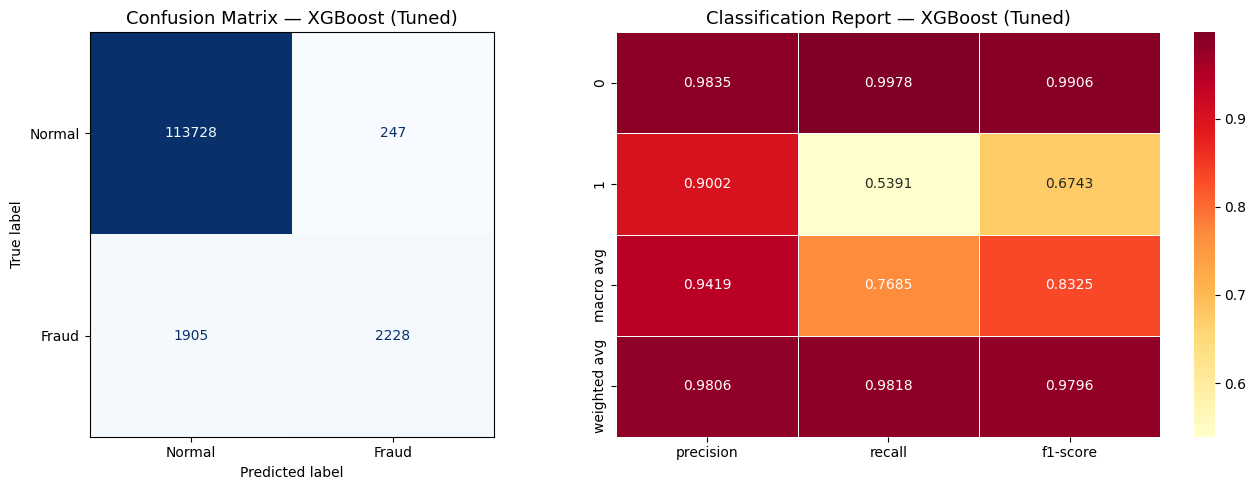


=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99    113975
       Fraud       0.90      0.54      0.67      4133

    accuracy                           0.98    118108
   macro avg       0.94      0.77      0.83    118108
weighted avg       0.98      0.98      0.98    118108



In [30]:
# Confusion Matrix
y_pred_best = (y_prob_tuned >= 0.5).astype(int)
cm = confusion_matrix(y_val, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=['Normal','Fraud']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — XGBoost (Tuned)', fontsize=13)

report = classification_report(y_val, y_pred_best, output_dict=True)
rep_df = pd.DataFrame(report).T.drop(['accuracy'], errors='ignore')
sns.heatmap(rep_df[['precision','recall','f1-score']].astype(float).round(4),
            annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('Classification Report — XGBoost (Tuned)', fontsize=13)
plt.tight_layout(); plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_val, y_pred_best, target_names=['Normal','Fraud']))


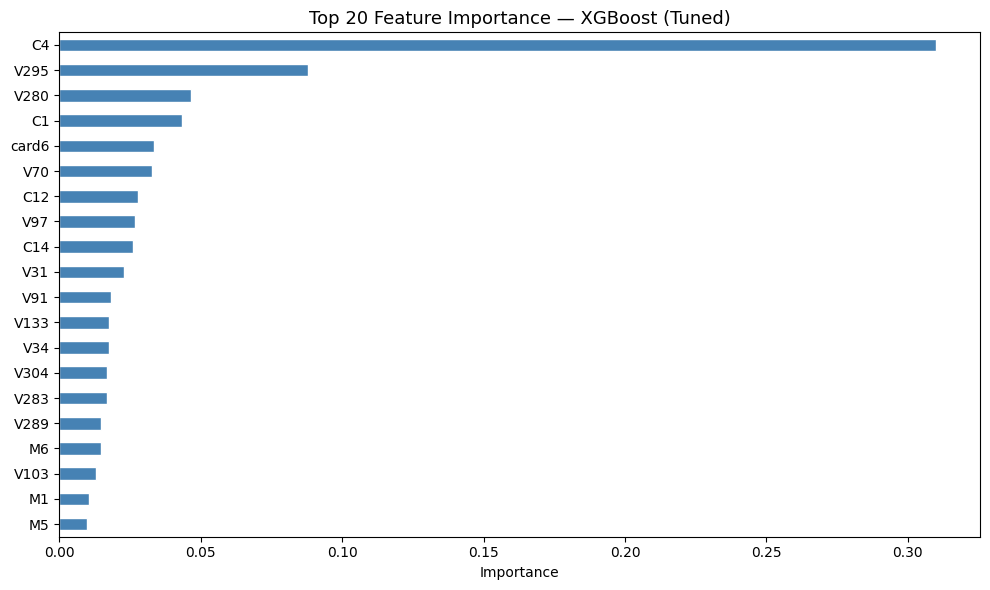

In [31]:
# Feature Importance
feat_imp = pd.Series(best_xgb.feature_importances_, index=X_train_sm.columns)
top20 = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 20 Feature Importance — XGBoost (Tuned)', fontsize=13)
plt.xlabel('Importance'); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()


## 9. 📤 Prediksi Test Set & Submission

In [32]:
print("Memprediksi test set...")

# Ambil kolom yang sama persis dengan training (X_train_sm)
train_features = X_train_sm.columns.tolist()

# Drop TransactionID dan kolom apapun yang tidak ada di training
test_aligned = test.drop(columns=["TransactionID"], errors="ignore")

# Tambah kolom yang ada di train tapi tidak di test (isi 0)
for col in train_features:
    if col not in test_aligned.columns:
        test_aligned[col] = 0

# Buang kolom yang ada di test tapi tidak di train
test_aligned = test_aligned[train_features]

print(f"Test shape setelah align: {test_aligned.shape}")
test_prob = best_xgb.predict_proba(test_aligned)[:,1]

submission = pd.DataFrame({"TransactionID": test_ids, "isFraud": test_prob})
print(f"Shape submission: {submission.shape}")
print(submission.head())

Memprediksi test set...
Test shape setelah align: (506691, 106)
Shape submission: (506691, 2)
   TransactionID   isFraud
0        3663549  0.001663
1        3663550  0.001569
2        3663551  0.005297
3        3663552  0.004782
4        3663553  0.004117


✅ Submission disimpan ke: /content/drive/MyDrive/submission_fraud.csv


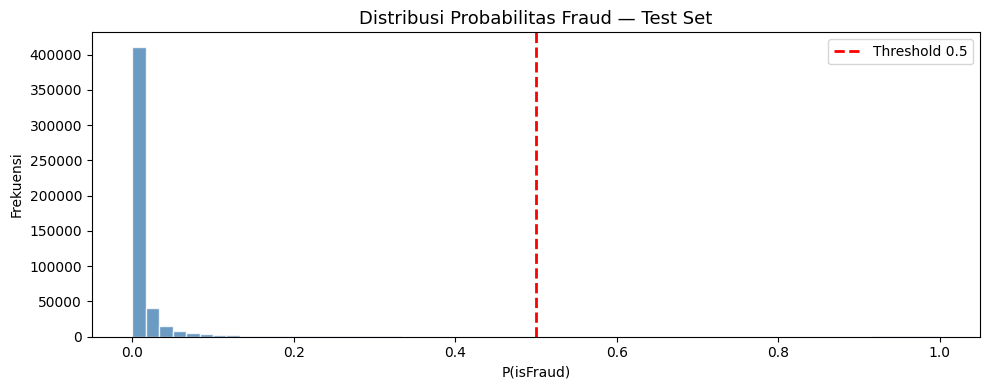

Prediksi fraud: 8,040 (1.59%)


In [33]:
# Simpan ke Drive
sub_path = DRIVE_PATH + 'submission_fraud.csv'
submission.to_csv(sub_path, index=False)
print(f"✅ Submission disimpan ke: {sub_path}")

plt.figure(figsize=(10, 4))
plt.hist(test_prob, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(0.5, color='red', linestyle='--', lw=2, label='Threshold 0.5')
plt.title('Distribusi Probabilitas Fraud — Test Set', fontsize=13)
plt.xlabel('P(isFraud)'); plt.ylabel('Frekuensi'); plt.legend()
plt.tight_layout(); plt.show()

fraud_pred = (test_prob >= 0.5).sum()
print(f"Prediksi fraud: {fraud_pred:,} ({fraud_pred/len(test_prob)*100:.2f}%)")


## 10. 📝 Kesimpulan

### Rangkuman Hasil Semua Model

| Model | AUC-ROC | F1-Fraud | Avg Precision | Time |
|---|---|---|---|---|
| Logistic Regression | 0.6789 | 0.0974 | 0.0688 | 130.7s |
| Random Forest | 0.8712 | 0.4574 | 0.4842 | 280.2s |
| XGBoost | 0.8968 | 0.5349 | 0.5471 | 54.8s |
| **XGBoost (Tuned)** | **0.9549** | **0.6743** | **0.7573** | — |

---

### Interpretasi

- **Model terbaik: XGBoost (Tuned)** dengan **AUC-ROC = 0.9549** dan **Average Precision = 0.7573** — peningkatan signifikan dari sebelum tuning (0.8968 → 0.9549).
- **AUC-ROC** dipilih sebagai metrik utama karena dataset sangat imbalanced (hanya **3.50% fraud** dari 590.540 transaksi).
- **Logistic Regression** memiliki performa paling rendah (AUC 0.6789) — menunjukkan hubungan antara fitur dan fraud bersifat **non-linear** dan kompleks.
- **XGBoost jauh lebih efisien** dibanding Random Forest: performa lebih tinggi (AUC 0.90 vs 0.87) dengan waktu training 5x lebih cepat (54s vs 280s).
- **SMOTE** berhasil menyeimbangkan data dari 3.5% menjadi 50/50 (455.902 per kelas), membantu model belajar pola fraud yang underrepresented.
- Dari confusion matrix: model mendeteksi **2.228 dari 4.133 fraud (recall 54%)** dengan precision 90% — dari semua yang diprediksi fraud, 90% memang benar fraud.
- **Fitur paling berpengaruh:** `C4`, `V295`, `V280`, `C1`, `card6` — kombinasi fitur frekuensi transaksi dan fitur-V hasil enkripsi.
- Pada test set, model memprediksi **8.040 transaksi fraud (1.59%)** dari 506.691 total transaksi.

---

### Optimasi RAM yang Diterapkan

| Teknik | Dampak |
|---|---|
| `dtype downcasting` float64→float32 | 756 MB → 256 MB (hemat 66%) |
| `usecols` — load kolom terpilih saja | Dari 394 kolom → 168 kolom |
| `del train` + `gc.collect()` | Bebaskan RAM segera setelah dipakai |
| `tree_method='hist'` pada XGBoost | Training lebih hemat memori |

---

### Saran Pengembangan
- Turunkan **threshold** di bawah 0.5 untuk meningkatkan recall fraud (false negative lebih mahal di kasus fraud)
- Coba **LightGBM** sebagai alternatif XGBoost yang lebih cepat
- Tambah **feature engineering** berbasis agregasi (transaksi per kartu, per email domain)
- Gabungkan dengan tabel **identity** untuk fitur tambahan (device, browser, OS)

